# 04 - Modeling

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, precision_recall_curve)

df = pd.read_csv('telco_churn_features.csv')  # already encoded, has AvgMonthlySpend + TenureGroup dummies
print(df.shape)

(7043, 36)


Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64


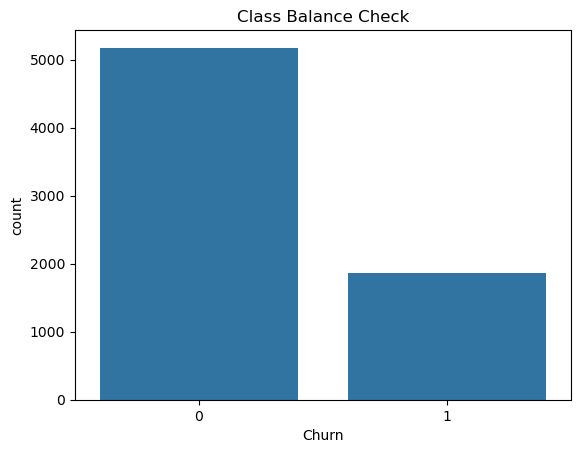

In [2]:
# Check class imbalance
print(df['Churn'].value_counts(normalize=True))
sns.countplot(x='Churn', data=df)
plt.title('Class Balance Check')
plt.show()

In [3]:
# Train-test split (stratified — important for imbalance)
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train shape:', X_train.shape, 'Test shape:', X_test.shape)
print('Train churn rate:', y_train.mean(), 'Test churn rate:', y_test.mean())

Train shape: (5634, 35) Test shape: (1409, 35)
Train churn rate: 0.2653532126375577 Test churn rate: 0.2654364797728886


In [4]:
# Scale numeric features (LR needs this, trees don't) — AvgMonthlySpend now actually exists
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlySpend']
num_cols = [c for c in num_cols if c in X_train.columns]

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

In [5]:
# Logistic Regression — with class_weight='balanced'
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred = log_reg.predict(X_test_scaled)
y_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.79      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

ROC-AUC: 0.8424733266165491


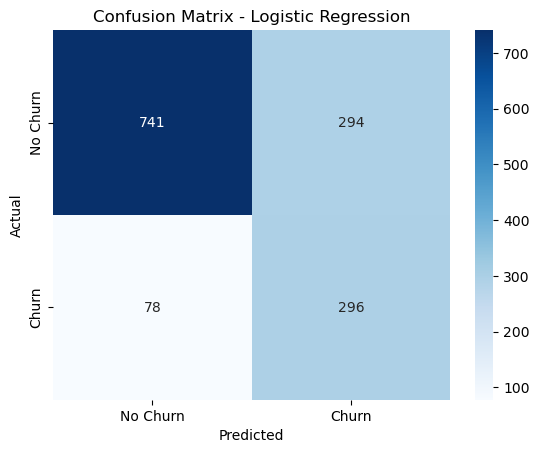

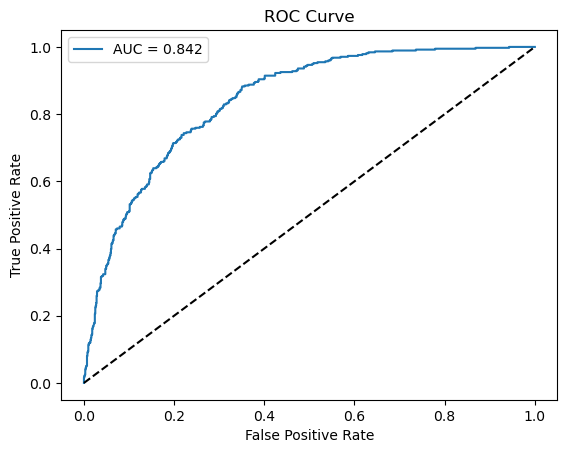

In [6]:
# Evaluation — Logistic Regression
print(classification_report(y_test, y_pred))
print('ROC-AUC:', roc_auc_score(y_test, y_proba))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_proba):.3f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [7]:
# Feature importance (coefficients)
coef_df = pd.DataFrame({'Feature': X_train_scaled.columns, 'Coefficient': log_reg.coef_[0]}).sort_values('Coefficient', key=abs, ascending=False)
print(coef_df.head(15))

                           Feature  Coefficient
26               Contract_Two year    -1.520372
11     InternetService_Fiber optic     1.100466
1                           tenure    -1.050122
25               Contract_One year    -0.725262
2                   MonthlyCharges    -0.512132
34                TenureGroup_5yr+     0.442628
29  PaymentMethod_Electronic check     0.393071
31               TenureGroup_1-2yr    -0.383326
24             StreamingMovies_Yes     0.380492
22                 StreamingTV_Yes     0.360879
27            PaperlessBilling_Yes     0.346849
33               TenureGroup_4-5yr     0.342689
10               MultipleLines_Yes     0.339731
14              OnlineSecurity_Yes    -0.335739
8                 PhoneService_Yes    -0.331739


In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for Random Forest (trees don't need explicit scaling, but need numerical features)
rf_X_train = X_train.copy()
rf_X_test = X_test.copy()

# Drop customerID from data as it's an identifier
rf_X_train = rf_X_train.drop('customerID', axis=1, errors='ignore')
rf_X_test = rf_X_test.drop('customerID', axis=1, errors='ignore')

# Identify remaining categorical columns (object type)
# Note: This finds columns that are still 'object' dtype after dropping customerID
rf_categorical_cols = rf_X_train.select_dtypes(include=['object']).columns

# Apply one-hot encoding to categorical columns in both train and test sets
rf_X_train = pd.get_dummies(rf_X_train, columns=rf_categorical_cols, drop_first=True)
rf_X_test = pd.get_dummies(rf_X_test, columns=rf_categorical_cols, drop_first=True)

# Ensure all columns in rf_X_test match rf_X_train after one-hot encoding
rf_train_cols = set(rf_X_train.columns)
rf_test_cols = set(rf_X_test.columns)

missing_in_rf_test = list(rf_train_cols - rf_test_cols)
for col in missing_in_rf_test:
    rf_X_test[col] = 0

missing_in_rf_train = list(rf_test_cols - rf_train_cols)
for col in missing_in_rf_train:
    rf_X_train[col] = 0

rf_X_test = rf_X_test[rf_X_train.columns]

#  Baseline Random Forest
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(rf_X_train, y_train)

y_pred_rf = rf.predict(rf_X_test)
y_proba_rf = rf.predict_proba(rf_X_test)[:, 1]


              precision    recall  f1-score   support

           0       0.89      0.78      0.83      1035
           1       0.55      0.73      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.78      1409

ROC-AUC (Random Forest): 0.8427252060244388


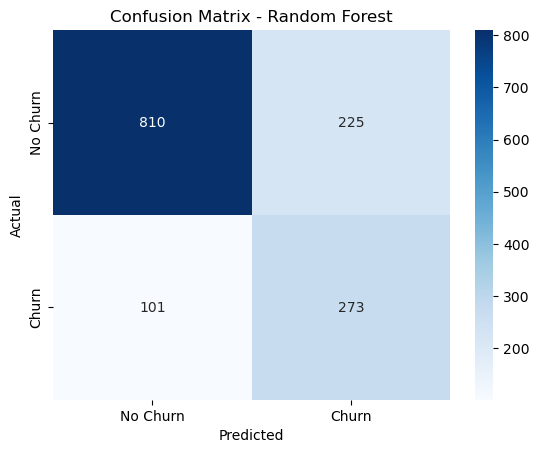

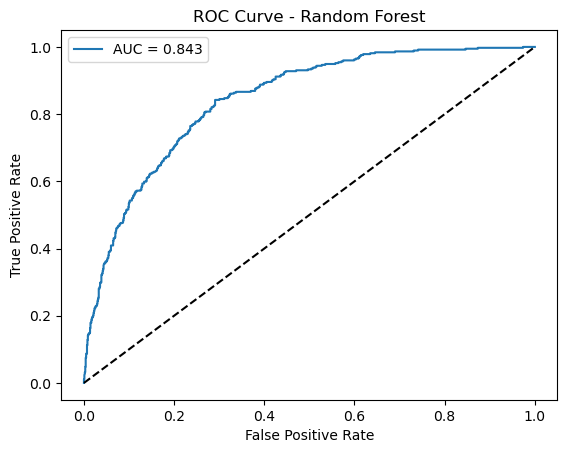

In [9]:
#  Evaluation of Random Forest
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC (Random Forest):", roc_auc_score(y_test, y_proba_rf))

# Confusion matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')
plt.show()

# ROC curve for Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
plt.plot(fpr_rf, tpr_rf, label=f'AUC = {roc_auc_score(y_test, y_proba_rf):.3f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend()
plt.show()

                               Feature  Importance
1                               tenure    0.142118
3                         TotalCharges    0.124765
26                   Contract_Two year    0.085169
4                      AvgMonthlySpend    0.083724
2                       MonthlyCharges    0.079730
11         InternetService_Fiber optic    0.062365
29      PaymentMethod_Electronic check    0.044326
25                   Contract_One year    0.036154
14                  OnlineSecurity_Yes    0.030387
34                    TenureGroup_5yr+    0.028211
20                     TechSupport_Yes    0.025836
27                PaperlessBilling_Yes    0.018346
19     TechSupport_No internet service    0.015387
15    OnlineBackup_No internet service    0.015161
13  OnlineSecurity_No internet service    0.014531


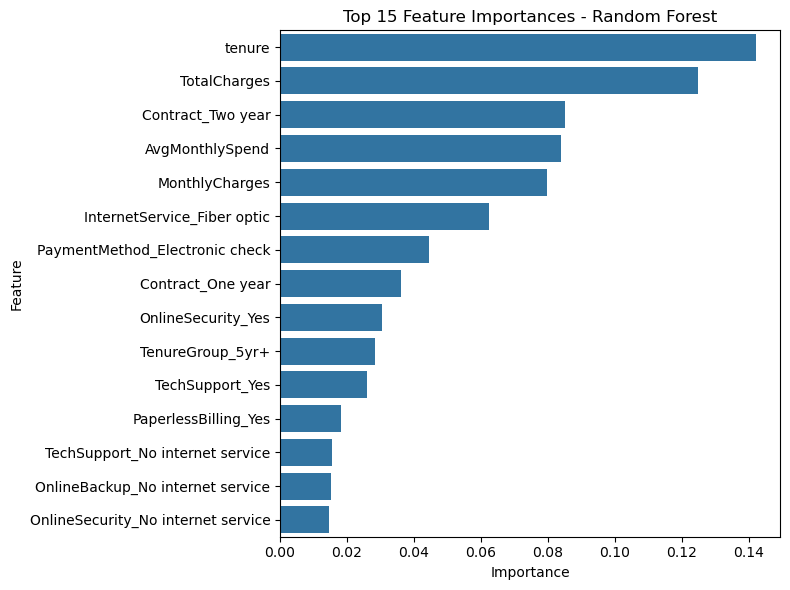

In [10]:
#  Feature importance
importance_df = pd.DataFrame({
    'Feature': rf_X_train.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print(importance_df.head(15))

plt.figure(figsize=(8, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(15))
plt.title('Top 15 Feature Importances - Random Forest')
plt.tight_layout()
plt.show()

In [11]:
#  Compare LR vs RF
print(f"Logistic Regression ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")
print(f"Random Forest ROC-AUC:       {roc_auc_score(y_test, y_proba_rf):.4f}")

Logistic Regression ROC-AUC: 0.8425
Random Forest ROC-AUC:       0.8427
